# train_enhance_v2_experiments

Reusable notebook for fast experimentation with geo labeling models.

What is included:
- leakage-safe holdout split by `Source_File`
- optional `StratifiedGroupKFold` CV
- rare-label merge fitted on train only
- multiple model families (`SGD`, `LinearSVC`, union TF-IDF, calibrated SVC)
- hierarchical `l1 -> l2` experiment
- multi-domain routing prototype (`Moscow`, `Regions`, and ready for `Genplan`)


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import f1_score, accuracy_score, classification_report

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

RANDOM_STATE = 44


In [2]:
# Paths and runtime switches
BASE = Path(r"C:/Users/artem/MAIN/projects/plain/local/python_modules/scripts/geo")

PATHS = {
    "Moscow": BASE / "labeled_msk_df.csv",
    "Regions": BASE / "labeled_regions_df_v6.csv",   # first choice
    "Regions_fallback": BASE / "labeled_regions_df.csv",
    "Genplan": BASE / "labeled_genplan_df.csv",       # optional, if/when appears
}

USECOLS = ["Source_File", "Layer", "Type", "Text", "l1", "l2"]

# QUICK_MODE=True: faster experiments on subset of files
QUICK_MODE = True
QUICK_N_GROUPS_MSK = 80
QUICK_N_GROUPS_REG = 40

TEST_SIZE = 0.2
VAL_SIZE_IN_TV = 0.2  # val fraction inside train+val pool

RARE_THRESHOLD_L1 = None
RARE_THRESHOLD_L2 = 100

RUN_CLASSIFICATION_REPORT = False


In [3]:
def resolve_regions_path() -> Path:
    if PATHS["Regions"].exists():
        return PATHS["Regions"]
    return PATHS["Regions_fallback"]


def load_df(path: Path, name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{name}: file not found -> {path}")

    df = pd.read_csv(path, usecols=USECOLS, low_memory=False)
    for col in ["Source_File", "Layer", "Type", "Text"]:
        df[col] = df[col].fillna("").astype(str)

    print(f"Loaded {name:<8} | rows={len(df):,} | files={df['Source_File'].nunique():,} | path={path.name}")
    return df


REGIONS_PATH = resolve_regions_path()
msk_df = load_df(PATHS["Moscow"], "Moscow")
reg_df = load_df(REGIONS_PATH, "Regions")


Loaded Moscow   | rows=180,953 | files=370 | path=labeled_msk_df.csv
Loaded Regions  | rows=3,069,680 | files=146 | path=labeled_regions_df.csv


In [4]:
def build_text_features(df: pd.DataFrame) -> pd.Series:
    # Keep source fields explicit, this often helps linear models separate patterns.
    return (
        "TYPE=" + df["Type"].astype(str) + " " +
        "LAYER=" + df["Layer"].astype(str) + " " +
        "TEXT=" + df["Text"].astype(str)
    )


def filter_non_empty_label(df: pd.DataFrame, label_col: str) -> pd.DataFrame:
    y = df[label_col].fillna("").astype(str).str.strip()
    return df[y != ""].copy()


def sample_groups(df: pd.DataFrame, n_groups: int, seed: int = RANDOM_STATE) -> pd.DataFrame:
    groups = pd.Series(df["Source_File"].unique())
    if n_groups >= len(groups):
        return df
    sampled = groups.sample(n=n_groups, random_state=seed)
    return df[df["Source_File"].isin(sampled)].copy()


def maybe_quick_subset(df: pd.DataFrame, name: str) -> pd.DataFrame:
    if not QUICK_MODE:
        return df
    if name == "Moscow":
        out = sample_groups(df, QUICK_N_GROUPS_MSK)
    elif name == "Regions":
        out = sample_groups(df, QUICK_N_GROUPS_REG)
    else:
        out = df
    print(f"{name:<8} quick subset -> rows={len(out):,}, files={out['Source_File'].nunique():,}")
    return out


In [5]:
class RareLabelMapper:
    def __init__(self, threshold: int | None = None, unknown_label: str = "unknown"):
        self.threshold = threshold
        self.unknown_label = unknown_label
        self.rare_labels_ = set()

    def fit(self, y: pd.Series):
        y = pd.Series(y).astype(str)
        if self.threshold is None:
            self.rare_labels_ = set()
            return self

        counts = y.value_counts()
        self.rare_labels_ = set(counts[counts < self.threshold].index)
        return self

    def transform(self, y: pd.Series) -> pd.Series:
        y = pd.Series(y).astype(str)
        if not self.rare_labels_:
            return y
        return y.where(~y.isin(self.rare_labels_), self.unknown_label)

    def fit_transform(self, y: pd.Series) -> pd.Series:
        return self.fit(y).transform(y)


In [6]:
def make_split_indices(X, y, groups, random_state=RANDOM_STATE):
    # First split off test by groups.
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=random_state)
    tv_idx, te_idx = next(gss.split(X, y, groups=groups))

    # Then split train/val inside train+val pool by groups.
    gss2 = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE_IN_TV, random_state=random_state)
    tr_idx_rel, va_idx_rel = next(
        gss2.split(X.iloc[tv_idx], y.iloc[tv_idx], groups=groups.iloc[tv_idx])
    )

    tr_idx = X.iloc[tv_idx].iloc[tr_idx_rel].index
    va_idx = X.iloc[tv_idx].iloc[va_idx_rel].index
    te_idx = X.iloc[te_idx].index

    return tr_idx, va_idx, te_idx


def build_cv(label_series: pd.Series, n_splits: int = 5, random_state: int = RANDOM_STATE):
    if HAS_STRATIFIED_GROUP_KFOLD:
        return StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # Fallback: less stable for imbalanced labels, but still group-safe.
    from sklearn.model_selection import GroupKFold
    return GroupKFold(n_splits=n_splits)


In [7]:
def make_sgd_char():
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=200_000,
        )),
        ("clf", SGDClassifier(
            loss="log_loss",
            alpha=1e-5,
            max_iter=40,
            tol=1e-3,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
        )),
    ])


def make_linear_svc_char(C=0.5, max_iter=12000):
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=220_000,
        )),
        ("clf", LinearSVC(
            C=C,
            max_iter=max_iter,
            class_weight="balanced",
            dual=False,
        )),
    ])


def make_linear_svc_union(C=0.5, max_iter=12000):
    return Pipeline([
        ("tfidf", FeatureUnion([
            ("char", TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                max_features=170_000,
            )),
            ("word", TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 2),
                min_df=2,
                max_features=70_000,
            )),
        ])),
        ("clf", LinearSVC(
            C=C,
            max_iter=max_iter,
            class_weight="balanced",
            dual=False,
        )),
    ])


def make_calibrated_union_svc(C=0.5, max_iter=12000, cv=3):
    base = make_linear_svc_union(C=C, max_iter=max_iter)
    return CalibratedClassifierCV(base_estimator=base, method="sigmoid", cv=cv)


In [8]:
def metrics_row(y_true, y_pred, split: str, extra: dict | None = None) -> dict:
    row = {
        "split": split,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "n_rows": len(y_true),
    }
    if extra:
        row.update(extra)
    return row


def run_holdout_experiment(
    *,
    df: pd.DataFrame,
    dataset_name: str,
    label_col: str,
    model_name: str,
    model_factory,
    rare_threshold: int | None = None,
    show_report: bool = False,
):
    work_df = filter_non_empty_label(df, label_col)
    X = build_text_features(work_df)
    y = work_df[label_col].fillna("").astype(str).str.strip()
    groups = work_df["Source_File"].astype(str)

    tr_idx, va_idx, te_idx = make_split_indices(X, y, groups)

    X_tr, X_va, X_te = X.loc[tr_idx], X.loc[va_idx], X.loc[te_idx]
    y_tr_raw, y_va_raw, y_te_raw = y.loc[tr_idx], y.loc[va_idx], y.loc[te_idx]

    mapper = RareLabelMapper(threshold=rare_threshold)
    y_tr = mapper.fit_transform(y_tr_raw)
    y_va = mapper.transform(y_va_raw)
    y_te = mapper.transform(y_te_raw)

    model = model_factory()
    model.fit(X_tr, y_tr)

    rows = []
    for split_name, xx, yy in [("train", X_tr, y_tr), ("val", X_va, y_va), ("test", X_te, y_te)]:
        pred = model.predict(xx)
        row = metrics_row(yy, pred, split=split_name, extra={
            "dataset": dataset_name,
            "label": label_col,
            "model": model_name,
            "classes_train": y_tr.nunique(),
            "rare_labels_merged": len(mapper.rare_labels_),
        })
        rows.append(row)

    if show_report:
        pred_te = model.predict(X_te)
        print(f"\n=== classification_report | {dataset_name} | {label_col} | {model_name} ===")
        print(classification_report(y_te, pred_te, zero_division=0))

    return pd.DataFrame(rows), model


In [9]:
def run_cv_experiment(
    *,
    df: pd.DataFrame,
    dataset_name: str,
    label_col: str,
    model_name: str,
    model_factory,
    rare_threshold: int | None = None,
    n_splits: int = 5,
):
    work_df = filter_non_empty_label(df, label_col)
    X = build_text_features(work_df)
    y_raw = work_df[label_col].fillna("").astype(str).str.strip()
    groups = work_df["Source_File"].astype(str)

    cv = build_cv(y_raw, n_splits=n_splits)
    fold_rows = []

    if HAS_STRATIFIED_GROUP_KFOLD:
        split_iter = cv.split(X, y_raw, groups=groups)
    else:
        split_iter = cv.split(X, y_raw, groups=groups)

    for fold, (tr_idx, te_idx) in enumerate(split_iter, start=1):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        y_tr_raw, y_te_raw = y_raw.iloc[tr_idx], y_raw.iloc[te_idx]

        mapper = RareLabelMapper(threshold=rare_threshold)
        y_tr = mapper.fit_transform(y_tr_raw)
        y_te = mapper.transform(y_te_raw)

        model = model_factory()
        model.fit(X_tr, y_tr)

        pred_te = model.predict(X_te)
        row = metrics_row(y_te, pred_te, split=f"cv_fold_{fold}", extra={
            "dataset": dataset_name,
            "label": label_col,
            "model": model_name,
            "classes_train": y_tr.nunique(),
            "rare_labels_merged": len(mapper.rare_labels_),
            "fold": fold,
        })
        fold_rows.append(row)

    fold_df = pd.DataFrame(fold_rows)
    summary = fold_df[["macro_f1", "weighted_f1", "accuracy"]].agg(["mean", "std"]).T
    summary.columns = ["cv_mean", "cv_std"]
    print(f"\nCV summary | {dataset_name} | {label_col} | {model_name}")
    display(summary)

    return fold_df


## 1) Holdout experiments (leakage-safe rare merge)

Tip:
- Keep `QUICK_MODE=True` while searching good configs.
- Turn it off for final numbers.


In [10]:
# msk_work = maybe_quick_subset(msk_df, "Moscow")
# reg_work = maybe_quick_subset(reg_df, "Regions")

# experiment_plan = [
#     ("Moscow", msk_work, "l1", "SGD-char", make_sgd_char, RARE_THRESHOLD_L1),
#     ("Moscow", msk_work, "l1", "LinearSVC-char", lambda: make_linear_svc_char(C=0.5), RARE_THRESHOLD_L1),
#     ("Moscow", msk_work, "l1", "LinearSVC-union", lambda: make_linear_svc_union(C=0.5), RARE_THRESHOLD_L1),
#     ("Moscow", msk_work, "l1", "LinearSVC-union-C1", lambda: make_linear_svc_union(C=1.0), RARE_THRESHOLD_L1),

#     ("Moscow", msk_work, "l2", "SGD-char", make_sgd_char, RARE_THRESHOLD_L2),
#     ("Moscow", msk_work, "l2", "LinearSVC-char", lambda: make_linear_svc_char(C=0.5), RARE_THRESHOLD_L2),
#     ("Moscow", msk_work, "l2", "LinearSVC-union", lambda: make_linear_svc_union(C=0.5), RARE_THRESHOLD_L2),
#     ("Moscow", msk_work, "l2", "LinearSVC-union-C1", lambda: make_linear_svc_union(C=1.0), RARE_THRESHOLD_L2),

#     ("Regions", reg_work, "l1", "SGD-char", make_sgd_char, RARE_THRESHOLD_L1),
#     ("Regions", reg_work, "l1", "LinearSVC-char", lambda: make_linear_svc_char(C=0.5), RARE_THRESHOLD_L1),
#     ("Regions", reg_work, "l1", "LinearSVC-union", lambda: make_linear_svc_union(C=0.5), RARE_THRESHOLD_L1),
#     ("Regions", reg_work, "l1", "LinearSVC-union-C1", lambda: make_linear_svc_union(C=1.0), RARE_THRESHOLD_L1),

#     ("Regions", reg_work, "l2", "SGD-char", make_sgd_char, RARE_THRESHOLD_L2),
#     ("Regions", reg_work, "l2", "LinearSVC-char", lambda: make_linear_svc_char(C=0.5), RARE_THRESHOLD_L2),
#     ("Regions", reg_work, "l2", "LinearSVC-union", lambda: make_linear_svc_union(C=0.5), RARE_THRESHOLD_L2),
#     ("Regions", reg_work, "l2", "LinearSVC-union-C1", lambda: make_linear_svc_union(C=1.0), RARE_THRESHOLD_L2),
# ]

# holdout_rows = []
# for dataset_name, data, label_col, model_name, factory, rare_thr in experiment_plan:
#     df_metrics, _ = run_holdout_experiment(
#         df=data,
#         dataset_name=dataset_name,
#         label_col=label_col,
#         model_name=model_name,
#         model_factory=factory,
#         rare_threshold=rare_thr,
#         show_report=RUN_CLASSIFICATION_REPORT,
#     )
#     holdout_rows.append(df_metrics)

# holdout_results = pd.concat(holdout_rows, ignore_index=True)
# holdout_results.head()


In [12]:
msk_work = maybe_quick_subset(msk_df, "Moscow")
reg_work = maybe_quick_subset(reg_df, "Regions")

experiment_plan = [
    ("Moscow",  msk_work, "l1", "SGD-char",        make_sgd_char, RARE_THRESHOLD_L1),
    ("Moscow",  msk_work, "l1", "LinearSVC-char",  lambda: make_linear_svc_char(C=0.5), RARE_THRESHOLD_L1),
    ("Moscow",  msk_work, "l2", "SGD-char",        make_sgd_char, RARE_THRESHOLD_L2),
    ("Moscow",  msk_work, "l2", "LinearSVC-char",  lambda: make_linear_svc_char(C=0.5), RARE_THRESHOLD_L2),
    ("Regions", reg_work, "l1", "SGD-char",        make_sgd_char, RARE_THRESHOLD_L1),
    ("Regions", reg_work, "l1", "LinearSVC-char",  lambda: make_linear_svc_char(C=0.5), RARE_THRESHOLD_L1),
    ("Regions", reg_work, "l2", "SGD-char",        make_sgd_char, RARE_THRESHOLD_L2),
    ("Regions", reg_work, "l2", "LinearSVC-char",  lambda: make_linear_svc_char(C=0.5), RARE_THRESHOLD_L2),
]

holdout_rows = []
for dataset_name, data, label_col, model_name, factory, rare_thr in experiment_plan:
    print(f"Running: {dataset_name} | {label_col} | {model_name}")
    df_metrics, _ = run_holdout_experiment(
        df=data,
        dataset_name=dataset_name,
        label_col=label_col,
        model_name=model_name,
        model_factory=factory,
        rare_threshold=rare_thr,
        show_report=False,
    )
    holdout_rows.append(df_metrics)

holdout_results = pd.concat(holdout_rows, ignore_index=True)
holdout_results.head()


Moscow   quick subset -> rows=70,891, files=80
Regions  quick subset -> rows=1,070,029, files=40
Running: Moscow | l1 | SGD-char
Running: Moscow | l1 | LinearSVC-char
Running: Moscow | l2 | SGD-char
Running: Moscow | l2 | LinearSVC-char
Running: Regions | l1 | SGD-char
Running: Regions | l1 | LinearSVC-char
Running: Regions | l2 | SGD-char
Running: Regions | l2 | LinearSVC-char


,split,macro_f1,weighted_f1,accuracy,n_rows,dataset,label,model,classes_train,rare_labels_merged
0,train,0.995110,0.998155,0.998150,41088,Moscow,l1,SGD-char,12,0
1,val,0.868803,0.979203,0.974166,2129,Moscow,l1,SGD-char,12,0
2,test,0.966177,0.993895,0.993893,27674,Moscow,l1,SGD-char,12,0
3,train,0.998282,0.999076,0.999075,41088,Moscow,l1,LinearSVC-char,12,0
4,val,0.869970,0.980114,0.975106,2129,Moscow,l1,LinearSVC-char,12,0


In [13]:
# Compare only TEST metrics
holdout_test = holdout_results[holdout_results["split"] == "test"].copy()
holdout_test = holdout_test.sort_values(["dataset", "label", "macro_f1"], ascending=[True, True, False])

for c in ["macro_f1", "weighted_f1", "accuracy"]:
    holdout_test[c] = holdout_test[c].round(4)

display(holdout_test[[
    "dataset", "label", "model", "macro_f1", "weighted_f1", "accuracy",
    "classes_train", "rare_labels_merged", "n_rows"
]])


,dataset,label,model,macro_f1,weighted_f1,accuracy,classes_train,rare_labels_merged,n_rows
2,Moscow,l1,SGD-char,0.9662,0.9939,0.9939,12,0,27674
5,Moscow,l1,LinearSVC-char,0.9624,0.9941,0.9941,12,0,27674
11,Moscow,l2,LinearSVC-char,0.9812,0.9958,0.9958,17,15,26482
8,Moscow,l2,SGD-char,0.9808,0.9954,0.9955,17,15,26482
17,Regions,l1,LinearSVC-char,0.9528,0.9734,0.9735,10,0,163225
14,Regions,l1,SGD-char,0.8404,0.9326,0.9096,10,0,163225
23,Regions,l2,LinearSVC-char,0.8856,0.9419,0.9242,31,7,163225
20,Regions,l2,SGD-char,0.8776,0.9551,0.9361,31,7,163225


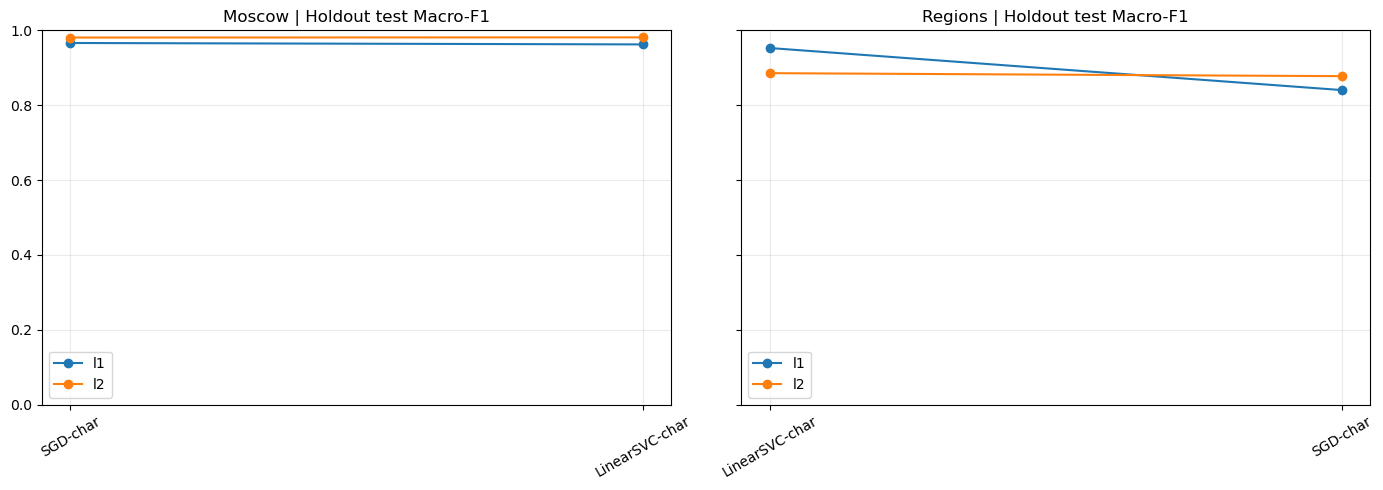

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, dataset in zip(axes, ["Moscow", "Regions"]):
    sub = holdout_test[holdout_test["dataset"] == dataset]
    for label, grp in sub.groupby("label"):
        grp = grp.sort_values("macro_f1", ascending=False)
        ax.plot(grp["model"], grp["macro_f1"], marker="o", label=label)
    ax.set_title(f"{dataset} | Holdout test Macro-F1")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()


## 2) CV sanity-check for top candidates

Use this after selecting a few best models from holdout.


In [ ]:
cv_plan = [
    ("Moscow", msk_work, "l2", "LinearSVC-union", lambda: make_linear_svc_union(C=0.5), RARE_THRESHOLD_L2),
    ("Regions", reg_work, "l2", "LinearSVC-union", lambda: make_linear_svc_union(C=0.5), RARE_THRESHOLD_L2),
]

cv_rows = []
for dataset_name, data, label_col, model_name, factory, rare_thr in cv_plan:
    fold_df = run_cv_experiment(
        df=data,
        dataset_name=dataset_name,
        label_col=label_col,
        model_name=model_name,
        model_factory=factory,
        rare_threshold=rare_thr,
        n_splits=5,
    )
    cv_rows.append(fold_df)

cv_results = pd.concat(cv_rows, ignore_index=True) if cv_rows else pd.DataFrame()
cv_results.head()



CV summary | Moscow | l2 | LinearSVC-union


,cv_mean,cv_std
macro_f1,0.937879,0.036558
weighted_f1,0.987714,0.006882
accuracy,0.987131,0.009666


In [ ]:
# Phase-2: точечные эксперименты без длинной сетки
# Предполагается, что функции/переменные уже есть в ноутбуке:
# run_holdout_experiment, make_linear_svc_char, make_linear_svc_union,
# maybe_quick_subset, msk_df, reg_df

import gc
import pandas as pd

msk_work = maybe_quick_subset(msk_df, "Moscow")
reg_work = maybe_quick_subset(reg_df, "Regions")

phase2_plan = [
    # Moscow l2: проверяем, не слишком ли агрессивен merge=100
    ("Moscow",  msk_work, "l2", "LinearSVC-char | rare=20",  lambda: make_linear_svc_char(C=0.5), 20),
    ("Moscow",  msk_work, "l2", "LinearSVC-char | rare=30",  lambda: make_linear_svc_char(C=0.5), 30),
    ("Moscow",  msk_work, "l2", "LinearSVC-char | rare=100", lambda: make_linear_svc_char(C=0.5), 100),

    # Regions l2: сравниваем char vs union
    ("Regions", reg_work, "l2", "LinearSVC-char | rare=100",  lambda: make_linear_svc_char(C=0.5), 100),
    ("Regions", reg_work, "l2", "LinearSVC-union | rare=100", lambda: make_linear_svc_union(C=0.5), 100),
]

phase2_rows, failed = [], []

for dataset_name, data, label_col, model_name, factory, rare_thr in phase2_plan:
    print(f"Running: {dataset_name} | {label_col} | {model_name}")
    try:
        df_metrics, _ = run_holdout_experiment(
            df=data,
            dataset_name=dataset_name,
            label_col=label_col,
            model_name=model_name,
            model_factory=factory,
            rare_threshold=rare_thr,
            show_report=False,
        )
        phase2_rows.append(df_metrics)
    except MemoryError as e:
        failed.append({
            "dataset": dataset_name,
            "label": label_col,
            "model": model_name,
            "error": str(e)[:180],
        })
        print(f"[MemoryError] skipped: {model_name}")
    finally:
        gc.collect()

phase2_results = pd.concat(phase2_rows, ignore_index=True) if phase2_rows else pd.DataFrame()

if not phase2_results.empty:
    phase2_test = (
        phase2_results[phase2_results["split"] == "test"]
        .sort_values(["dataset", "macro_f1"], ascending=[True, False])
        .copy()
    )
    for c in ["macro_f1", "weighted_f1", "accuracy"]:
        phase2_test[c] = phase2_test[c].round(4)
    display(phase2_test[[
        "dataset", "label", "model", "macro_f1", "weighted_f1",
        "accuracy", "classes_train", "rare_labels_merged", "n_rows"
    ]])

if failed:
    print("\nFailed runs:")
    display(pd.DataFrame(failed))


## 3) Hierarchical experiment (`l1 -> l2`)

Idea:
- train one model for `l1`
- train local `l2` models per `l1` class
- fallback to global `l2` model if local model is unavailable


In [ ]:
def run_hierarchical_l1_l2(
    *,
    df: pd.DataFrame,
    dataset_name: str,
    l1_model_factory,
    l2_model_factory,
    rare_threshold_l2: int | None = None,
    min_local_support: int = 200,
):
    work_df = df.copy()
    y1 = work_df["l1"].fillna("").astype(str).str.strip()
    y2 = work_df["l2"].fillna("").astype(str).str.strip()
    mask = (y1 != "") & (y2 != "")
    work_df = work_df[mask].copy()

    X = build_text_features(work_df)
    y1 = work_df["l1"].astype(str)
    y2_raw = work_df["l2"].astype(str)
    groups = work_df["Source_File"].astype(str)

    tr_idx, va_idx, te_idx = make_split_indices(X, y1, groups)

    X_tr, X_va, X_te = X.loc[tr_idx], X.loc[va_idx], X.loc[te_idx]
    y1_tr, y1_va, y1_te = y1.loc[tr_idx], y1.loc[va_idx], y1.loc[te_idx]
    y2_tr_raw, y2_va_raw, y2_te_raw = y2_raw.loc[tr_idx], y2_raw.loc[va_idx], y2_raw.loc[te_idx]

    mapper_l2 = RareLabelMapper(threshold=rare_threshold_l2)
    y2_tr = mapper_l2.fit_transform(y2_tr_raw)
    y2_va = mapper_l2.transform(y2_va_raw)
    y2_te = mapper_l2.transform(y2_te_raw)

    l1_model = l1_model_factory()
    l1_model.fit(X_tr, y1_tr)

    # Global fallback for l2.
    l2_global = l2_model_factory()
    l2_global.fit(X_tr, y2_tr)

    # Local models per l1 class.
    l2_local = {}
    y1_counts = y1_tr.value_counts()
    for cls, cnt in y1_counts.items():
        if cnt < min_local_support:
            continue
        idx = y1_tr[y1_tr == cls].index
        y2_subset = y2_tr.loc[idx]
        if y2_subset.nunique() < 2:
            continue
        mdl = l2_model_factory()
        mdl.fit(X_tr.loc[idx], y2_subset)
        l2_local[cls] = mdl

    def predict_hierarchical(xx):
        p1 = pd.Series(l1_model.predict(xx), index=xx.index)
        p2 = []
        for i, cls in p1.items():
            mdl = l2_local.get(cls, None)
            if mdl is None:
                pred_l2 = l2_global.predict(xx.loc[[i]])[0]
            else:
                pred_l2 = mdl.predict(xx.loc[[i]])[0]
            p2.append(pred_l2)
        return p1, pd.Series(p2, index=xx.index)

    rows = []
    for split_name, xx, yy1, yy2 in [
        ("train", X_tr, y1_tr, y2_tr),
        ("val", X_va, y1_va, y2_va),
        ("test", X_te, y1_te, y2_te),
    ]:
        p1, p2 = predict_hierarchical(xx)
        row_l1 = metrics_row(yy1, p1, split_name, extra={
            "dataset": dataset_name,
            "label": "l1",
            "model": "hierarchical(l1->l2)-l1",
            "classes_train": y1_tr.nunique(),
            "rare_labels_merged": 0,
            "local_l2_models": len(l2_local),
        })
        row_l2 = metrics_row(yy2, p2, split_name, extra={
            "dataset": dataset_name,
            "label": "l2",
            "model": "hierarchical(l1->l2)-l2",
            "classes_train": y2_tr.nunique(),
            "rare_labels_merged": len(mapper_l2.rare_labels_),
            "local_l2_models": len(l2_local),
        })
        rows.extend([row_l1, row_l2])

    return pd.DataFrame(rows)


In [ ]:
hier_regions = run_hierarchical_l1_l2(
    df=reg_work,
    dataset_name="Regions",
    l1_model_factory=lambda: make_linear_svc_union(C=0.5),
    l2_model_factory=lambda: make_linear_svc_union(C=0.5),
    rare_threshold_l2=RARE_THRESHOLD_L2,
    min_local_support=200,
)

hier_moscow = run_hierarchical_l1_l2(
    df=msk_work,
    dataset_name="Moscow",
    l1_model_factory=lambda: make_linear_svc_union(C=0.5),
    l2_model_factory=lambda: make_linear_svc_union(C=0.5),
    rare_threshold_l2=RARE_THRESHOLD_L2,
    min_local_support=100,
)

hier_results = pd.concat([hier_regions, hier_moscow], ignore_index=True)
hier_results[hier_results["split"] == "test"].sort_values(["dataset", "label", "macro_f1"], ascending=[True, True, False])


## 4) Multi-domain routing prototype

This mirrors future production setup with multiple heads:
- domain router (`Moscow`, `Regions`, `Genplan`)
- separate domain head models for target label

For now, this cell runs with `Moscow + Regions` and is ready to include `Genplan` once data is available.


In [ ]:
def run_domain_routing(df_map: dict[str, pd.DataFrame], label_col: str = "l2"):
    parts = []
    for domain, ddf in df_map.items():
        tmp = ddf.copy()
        tmp["domain"] = domain
        tmp = filter_non_empty_label(tmp, label_col)
        parts.append(tmp)

    all_df = pd.concat(parts, ignore_index=True)
    X = build_text_features(all_df)
    domain_y = all_df["domain"].astype(str)
    groups = all_df["Source_File"].astype(str)

    tr_idx, va_idx, te_idx = make_split_indices(X, domain_y, groups)

    X_tr, X_te = X.loc[tr_idx], X.loc[te_idx]
    d_tr, d_te = domain_y.loc[tr_idx], domain_y.loc[te_idx]

    # Router model
    router = make_linear_svc_union(C=0.5)
    router.fit(X_tr, d_tr)
    d_pred = pd.Series(router.predict(X_te), index=X_te.index)

    # Domain-specific heads
    heads = {}
    for domain in sorted(all_df["domain"].unique()):
        local_idx = tr_idx.intersection(all_df.index[all_df["domain"] == domain])
        y_local = all_df.loc[local_idx, label_col].astype(str)
        if len(local_idx) < 50 or y_local.nunique() < 2:
            continue
        mdl = make_linear_svc_union(C=0.5)
        mdl.fit(X.loc[local_idx], y_local)
        heads[domain] = mdl

    # Inference with predicted domain
    y_true = all_df.loc[te_idx, label_col].astype(str)
    y_pred = []
    for i in te_idx:
        domain_hat = d_pred.loc[i]
        mdl = heads.get(domain_hat)
        if mdl is None:
            # fallback: router domain unseen in head dict (unlikely)
            fallback_domain = d_te.loc[i]
            mdl = heads.get(fallback_domain)
        y_pred.append(mdl.predict(X.loc[[i]])[0])

    y_pred = pd.Series(y_pred, index=te_idx)

    out = {
        "router_acc": accuracy_score(d_te, d_pred),
        "downstream_macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "downstream_weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "n_test": len(te_idx),
        "n_heads": len(heads),
    }
    return out


In [ ]:
routing_metrics = run_domain_routing({
    "Moscow": msk_work,
    "Regions": reg_work,
}, label_col="l2")

routing_metrics


## 5) Add Genplan head (template)

When `labeled_genplan_df.csv` is available:
1. load it as `gen_df`
2. add to `run_domain_routing({...})`
3. add holdout and CV lines for `dataset='Genplan'`

Example:
```python
if PATHS["Genplan"].exists():
    gen_df = load_df(PATHS["Genplan"], "Genplan")
    gen_work = maybe_quick_subset(gen_df, "Genplan")
```


## Notes
- If metrics fluctuate strongly between val/test, prefer repeated `StratifiedGroupKFold` reports.
- For production scoring, consider probability calibration (`CalibratedClassifierCV`) and confidence threshold routing to `unknown`.
- For fast retraining by domain, keep one shared feature recipe and separate domain heads.
